In [1]:
# Standard library
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score

# Project modules
from data import build_combined_dataset
from pca import (
    run_pca_pipeline, plot_scree, plot_cumulative_variance,
    plot_biplot, FEATURE_COLS,
)
from clustering.clustering_kmeans import (
    tune_kmeans, fit_kmeans, cluster_summary as km_summary,
    plot_elbow, plot_ch_score, plot_silhouette,
)
from clustering.clustering_hierarchical import (
    fit_ward, fit_bisecting_kmeans,
    cluster_summary as hier_summary,
    plot_dendrogram, plot_fusion_levels,
)
from clustering.clustering_density import (
    tune_eps, fit_dbscan, cluster_summary as db_summary,
)
from clustering.utils import (
    plot_clustering, plot_cluster_averages, plot_neighbor_distances,
)

# Display options
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# Toggle the raw-code visibility for a cleaner reading experience
from IPython.display import HTML
HTML('''<script>
code_show=true;
function code_toggle() {
 if (code_show){ $('div.input').hide(); }
 else { $('div.input').show(); }
 code_show = !code_show;
}
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="Click to toggle on/off the raw code.">
</form>''')

# F1 Driver Archetypes: Discovering Performance Personas Through Clustering

**DMW 2301 — Data Mining and Wrangling, Mini Project 2**


## 1 Executive Summary


This project addresses the challenge of objectively evaluating Formula 1 driver careers, which are often obscured by narrative bias and multifaceted performance dimensions like qualifying pace, race-day consistency, and car reliability. To establish a data-driven taxonomy, we utilized a Kaggle dataset of official Fédération Internationale de l'Automobile (FIA) records from the Ergast API. Restricting our scope to the 2000–2024 seasons, we filtered for the 77 drivers who achieved at least 30 career starts. We engineered eight distinct performance metrics per driver and applied a robust preprocessing pipeline—including standardization and Principal Component Analysis (PCA)—to reduce dimensionality while retaining 94.1% of the total variance. We then systematically evaluated and tuned three clustering algorithms: K-Means, Ward's hierarchical clustering, and DBSCAN.

The analytical pipeline showed that driver performance occupies a continuous gradient rather than isolated density groups, with K-Means and Ward's clustering achieving perfect alignment (ARI = 1.000) on a four-cluster solution. These performance archetypes cleanly partition the grid into *Generational Champions* (n = 5), *Podium Contenders* (n = 19), *Midfield Mainstays* (n = 30), and *Backmarker Survivors* (n = 23). Our hope is that F1 teams, motorsport media, and analytics vendors adopt this reproducible, multi-dimensional framework as an objective baseline for talent scouting, driver comparisons, and predictive fantasy modeling, moving past anecdotal shorthand to evaluate a driver's true statistical footprint.

## 2 Introduction


Formula 1 is the apex of single-seater motorsport. Each season, 20 drivers across 10 constructors contest twenty-plus Grands Prix at venues spanning five continents, and the championship leaderboard is the principal artifact by which careers are remembered. Yet the championship table is a single ranked column. Two drivers who finish a season twelfth and fourteenth in the standings may have arrived at those positions through entirely different careers—one a former race winner now in declining machinery, the other a steady midfield qualifier in his rookie year. The standings collapse a multidimensional performance space onto one axis.

The motorsport press routinely supplements the standings with informal labels: "ace", "journeyman", "backmarker", "veteran", "rookie", "pay driver". These labels carry real information, but they are applied inconsistently and without quantitative criteria. A driver may be called a backmarker in one article and a journeyman in another, depending on the writer's frame of reference. This inconsistency is a problem for fans trying to learn the sport, for teams trying to benchmark signings, and for analysts building downstream models that require a stable taxonomy of driver types.

In this project, we want to answer the question, ***"Do Formula 1 driver careers fall into distinct performance archetypes, and how would an objective, data-driven taxonomy partition the modern grid?"*** We restrict our scope to the seasons 2000-2024—a window large enough to include three generations of drivers and four major regulation cycles, yet recent enough that qualifying-pace and fastest-lap-speed statistics are consistently recorded. We collected race and qualifying data from the Ergast Motor Racing Developer API sourced via Kaggle, engineered eight per-driver features, reduced them to three principal components, and clustered the drivers using three complementary algorithms. In our analysis, we describe the resulting partition both quantitatively (cluster centroids in feature space) and qualitatively (the drivers each cluster contains) so that the archetypes are both defensible and recognisable.

Here are the steps we did to tackle this problem:

First, we obtained Formula 1 race and qualifying data from Kaggle that utilized Ergast Motor Racing Developer API to compile official FIA records of every World Championship since 1950. We restricted the data to seasons 2000-2024 and to drivers with at least 30 career starts in that window, yielding a clean per-driver feature table of 77 rows.

Second, we engineered eight performance features per driver: average finishing position, average grid position, average points per race, win rate, podium rate, did-not-finish (DNF) rate, average fastest-lap speed, and average best qualifying time. These features span four distinct facets of a driver's career—race-day performance, qualifying pace, peak performance frequency, and reliability.

Third, we built a preprocessing pipeline consisting of median imputation, standardization, and Principal Component Analysis. Standardization is mandatory before PCA so that features with larger numeric ranges do not dominate the components purely because of their scale. PCA reduced the eight features to three components that together explain **94.1%** of the total variance, with the first component alone accounting for **71%**.

Fourth, we applied three clustering algorithms—K-Means (partitional), Ward's agglomerative hierarchical clustering (hierarchical, bottom-up), and DBSCAN (density-based)—and tuned their hyperparameters systematically. K-Means tuning used the Calinski-Harabasz score across multiple random seeds; Ward's was cut at the same k for direct comparability; DBSCAN's epsilon was set using the tau-nearest-neighbour z-score method.

Finally, we interpreted the resulting partition by examining cluster centroids in the original feature space and inspecting the drivers assigned to each cluster.

We found that **four archetypes** emerge cleanly from the data. K-Means and Ward agreed perfectly (Adjusted Rand Index = 1.000), and Bisecting K-Means agreed with both at ARI = 0.961. DBSCAN, on the other hand, returned a single cluster with zero noise points, indicating that driver performance lies on a **continuous gradient** rather than in density-separated islands. We named the four archetypes:

1. **Generational Champions** (n = 5) — Hamilton, M. Schumacher, Vettel, Häkkinen, Verstappen
2. **Podium Contenders** (n = 19) — established frontrunners with regular but non-dominant success
3. **Midfield Mainstays** (n = 30) — competent point-scorers and qualifiers in mid-grid machinery
4. **Backmarker Survivors** (n = 23) — drivers from backmarker teams whose careers were defined by car limitations

Our results provide value to three stakeholder groups: (1) **F1 teams and talent scouts**, who can use the archetype boundaries as an objective baseline when evaluating prospective signings against the current grid; (2) **broadcasters and the motorsport press**, who can ground driver comparisons in a defensible taxonomy rather than narrative shorthand; and (3) **fantasy F1 platforms and analytics vendors**, who can use the archetype membership and centroid distances as features in downstream predictive models.

Some extensions of the study include extending the era to cover the full hybrid-engine generation as it completes, adding race-craft features such as overtake counts and stint-pace consistency, and modelling the cluster trajectory of individual drivers as they move between teams.

Our hope is that further extensions of the study will help fans, teams, and analysts move from anecdotal driver comparisons toward an objective, reproducible language for talking about Formula 1 careers.


### Business Value


Formula 1 is a multi-billion-dollar global sport with deep commercial ecosystems around teams, broadcasters, sponsors, and increasingly, sports-analytics vendors. An objective taxonomy of driver performance creates value across this ecosystem. This project aims to provide value to the following stakeholders:

- **F1 teams and talent scouts** make multi-million-dollar decisions when signing drivers, often under tight contract windows and incomplete benchmarks. Through this project, scouts can place a prospective signing on the same coordinate system as every active and recent driver, see which archetype their performance most resembles, and quantify the distance between their record and the centroid of any target archetype. This complements—and disciplines—the qualitative scouting process.

- **Corporate Sponsors & Global brands** deploy hundreds of millions in sponsorship capital to tie their corporate identities to specific F1 drivers and teams. This taxonomy provides chief marketing officers (CMOs) and brand strategists with an empirical framework to evaluate corporate alignment and risk. Rather than overpaying for a driver based purely on subjective hype, brands can audit a driver’s statistical profile to ensure their performance matches the corporate narrative.

- **Fantasy F1 platforms and analytics vendors** are one of the fastest-growing parts of the motorsport ecosystem, including platforms such as the official F1 Fantasy game and third-party prediction markets. They can use this project's cluster memberships and centroid distances as engineered features in downstream regression and ranking models for race outcomes, season-finishing position, and driver-of-the-day predictions. The archetype label is a stable, low-cardinality feature that captures a great deal of latent career information in a single column.


## 3 Data


A driver's Formula 1 career is, at its core, a sequence of race weekends. Each weekend produces a small set of measurable outcomes: where they qualified, where they finished, how many points they scored, whether they completed the race, and how fast their fastest lap was. Aggregated across an entire career, these per-weekend outcomes show a detailed picture of the driver's performance, machinery, and reliability. Prior motorsport-analytics literature has shown that a relatively small number of such aggregated metrics is sufficient to explain a large fraction of the variance in subjective driver rankings (Bell, Smith, Sabel, & Jones, 2016; Eichenberger & Stadelmann, 2009). In this section, we will outline how we extracted information from Kaggle and give a brief description of the dataset we used in the analysis.


### 3.1 Data Extraction


There are several public sources of historical Formula 1 data, including the FIA's official site, the F1 statistics archive on `formula1.com`, third-party fan databases such as `statsf1.com`, and Kaggle dataset mirrors. We chose the **Kaggle** dataset which utilized **Ergast Motor Racing Developer API** as our primary source. Ergast is a free, openly licensed REST API that compiles official FIA results for every World Championship session from 1950 onwards and is widely used in motorsport-analytics research ([Ergast Developer API], n.d.). The API exposes structured CSV exports that are version-stable, well documented, and directly usable in a reproducible pipeline. Here are some brief information about the source files we used.

- **`results.csv`**: One row per driver per race start, containing the grid position, finishing position, points scored, fastest-lap speed, and a foreign key to the status table. This is the workhorse of the project.

- **`drivers.csv`**: One row per driver, containing forename, surname, nationality, and a stable `driverId` used to join the other tables.

- **`races.csv`**: One row per Grand Prix, containing the season year. We use this to filter to the 2000-2024 era.

- **`qualifying.csv`**: One row per driver per qualifying session, containing Q1, Q2, and Q3 lap-time strings (e.g. `"1:26.572"`). Available consistently from the 2003 season onwards.

- **`status.csv`**: A lookup table that maps the `statusId` foreign key in `results` to a human-readable finishing status (`"Finished"`, `"Accident"`, `"Engine"`, and so on). We use this to derive DNF flags.

Our data extraction pipeline is implemented in `data.py` and consists of the following steps:

1. Load the five raw CSVs using `load_raw_data`, treating the literal string `\N` as a missing value (this is the Ergast convention for nulls).
2. Restrict the results table to races between seasons 2000 and 2024 using `filter_to_era`. The lower bound is chosen because qualifying lap-time data only becomes consistently available from the early 2000s; the upper bound is the most recently completed season at the time of writing.
3. Attach a boolean `dnf` flag to each result using `compute_dnf_flags`. Any status other than `"Finished"` counts as a DNF. This includes accidents, mechanical failures, collisions, and disqualifications.
4. Compute each driver's average best qualifying lap time using `compute_qualifying_pace`. For each qualifying session, we convert Q1, Q2, and Q3 strings to seconds via `lap_time_to_seconds`, take the minimum of the three (the driver's fastest effort that weekend), and average that minimum across all sessions per driver. Using the best-of-three is the fairest cross-grid comparison because not all drivers reach Q2 or Q3 in a given weekend.
5. Aggregate the per-race results into per-driver features using `build_driver_features`, joining the qualifying pace from step 4 and dropping any driver with fewer than 30 race starts within the era.
6. Save the resulting feature table to `data/combined/data.csv`.

The minimum-races threshold of 30 (roughly 1.5 full modern seasons) is a methodological choice we adopt to ensure that each driver's aggregated statistics are based on a stable sample. Drivers with fewer starts than this, typically one-off substitutes or rookies who lost their seat partway through their debut season, would otherwise contribute extremely noisy rows whose feature values are dominated by sampling variance.

The functions and code we used to obtain the data frame is shown below. They are implemented in `data.py` and invoked from this notebook through the `build_combined_dataset` pipeline entry point.


In [2]:
# Build the combined per-driver feature table from raw Ergast CSVs.
# This calls the pipeline defined in data.py and writes data/combined/data.csv.
# df = build_combined_dataset()

df = pd.read_csv("data/combined/data.csv")
print(f"Combined dataset shape: {df.shape}")

Combined dataset shape: (77, 12)


### 3.2 Data Description


After applying the era filter and the minimum-races threshold, our dataset contains **77 drivers**, each described by 8 engineered numeric features and 4 metadata columns. The 8 numeric features are the input to the downstream PCA and clustering pipeline; the metadata columns (driver name, nationality, total races, and the Ergast driver ID) are kept for labelling plots and interpreting clusters but are never fed into the model. The dataset descriptions and data type are shown in **Table 1**.


<center style="font-size:12px;font-style:default;"><b>Table 1. F1 driver dataset — feature names, data types, and descriptions.</b></center>

| Data | Data type | Description |
|---|---|---|
| `driverId` | INTEGER | Ergast unique identifier for the driver (metadata, not used in modelling) |
| `driver_name` | TEXT | Full name of the driver (metadata) |
| `nationality` | TEXT | Driver's declared racing nationality (metadata) |
| `total_races` | INTEGER | Number of Grand Prix starts within 2000-2024 (metadata) |
| `avg_finish_position` | FLOAT | Mean finishing order across all entered races (lower is better) |
| `avg_grid_position` | FLOAT | Mean qualifying grid position across all sessions (lower is better) |
| `avg_points_per_race` | FLOAT | Mean championship points scored per race |
| `win_rate` | FLOAT | Proportion of races finished in P1 |
| `podium_rate` | FLOAT | Proportion of races finished in P1-P3 |
| `dnf_rate` | FLOAT | Proportion of races where the driver did not finish |
| `avg_fastest_lap_speed` | FLOAT | Mean recorded fastest-lap speed in km/h |
| `avg_best_quali_time` | FLOAT | Mean best of Q1/Q2/Q3 lap time in seconds |


We want to identify the feature type and subtype of each variable, since this determines the appropriate descriptive statistics, plots, and modelling treatment. The feature type and subtype for our dataset is shown in **Table 2**.


<center style="font-size:12px;font-style:default;"><b>Table 2. F1 driver dataset — feature type and subtype classification.</b></center>

| Data | Feature Type | Subtype |
|---|---|---|
| `driver_name` | Categorical | Nominal |
| `nationality` | Categorical | Nominal |
| `total_races` | Numerical | Discrete |
| `avg_finish_position` | Numerical | Continuous - Ratio |
| `avg_grid_position` | Numerical | Continuous - Ratio |
| `avg_points_per_race` | Numerical | Continuous - Ratio |
| `win_rate` | Numerical | Continuous - Ratio (bounded [0, 1]) |
| `podium_rate` | Numerical | Continuous - Ratio (bounded [0, 1]) |
| `dnf_rate` | Numerical | Continuous - Ratio (bounded [0, 1]) |
| `avg_fastest_lap_speed` | Numerical | Continuous - Ratio |
| `avg_best_quali_time` | Numerical | Continuous - Ratio |


All eight modelling features are numerical and continuous on the ratio scale, which makes the dataset directly suitable for the standardisation-then-PCA pipeline we apply in the next section. The three rate features (`win_rate`, `podium_rate`, `dnf_rate`) are bounded on [0, 1] but, on the bounded interval, behave indistinguishably from any other ratio variable for PCA purposes. We show a sample of the dataset in **Table 3** for us to further visualise the data and how each data type is reflected.


<center style="font-size:12px;font-style:default;"><b>Table 3. Sample raw rows from the F1 driver dataset.</b></center>


In [3]:
df.head(5)

,driverId,driver_name,nationality,total_races,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time
0,1,Lewis Hamilton,British,356,5.0197,4.3006,13.5407,0.2949,0.5674,0.1236,206.5222,86.7523
1,2,Nick Heidfeld,German,184,10.7228,11.3370,1.4076,0.0000,0.0707,0.6413,204.0446,85.8870
2,3,Nico Rosberg,German,206,8.2524,6.9029,7.7403,0.1117,0.2767,0.2961,200.2904,88.8217
3,4,Fernando Alonso,Spanish,404,8.4926,8.5792,5.7649,0.0792,0.2624,0.3540,205.3396,87.0678
4,5,Heikki Kovalainen,Finnish,112,13.2857,13.7411,0.9375,0.0089,0.0357,0.6518,198.2462,90.7323


## 4 Data Exploration


We now have 8 numerical features (excluding the metadata columns) on which we can build a clustering analysis. Before applying any algorithm, we will first look at and describe the characteristics of the features, then investigate their relationships, then design the dimensionality-reduction and clustering pipeline that turns them into archetypes. We do this sequentially and progressively. Here is an outline of what to expect in the succeeding subsections.

- **Univariate analysis**: We look at and characterise each feature on its own, helping us decide how to deal with missing values and outliers, and which features are likely to drive the clustering.
- **Missing values and outliers**: We discuss the small number of missing values present in the data and the action we take to handle them.
- **Bivariate analysis**: We look at how pairs of features behave in conjunction, in particular the strong correlations among the eight features that motivate the use of PCA.
- **Dimensionality reduction**: We apply standardisation and PCA, decide how many components to retain, and interpret the loadings.
- **Hyperparameter tuning and clustering**: We tune K-Means via three internal validity indices, fit hierarchical (Ward) and density-based (DBSCAN) clustering for triangulation, and compare the three partitions.
- **Driver archetype interpretation**: We name the resulting clusters using the centroid feature profiles and the drivers each cluster contains, addressing the core research question of the paper.


### 4.1 Univariate Analysis


In this subsection, we looked at all eight numerical features and analyse them appropriately based on their feature type.

- **Descriptive statistics**: We compute the standard five-number summary plus mean and standard deviation for each feature. This tells us the scale, central tendency, and spread of each variable, and exposes any obvious skew that would distort downstream PCA.
- **Distribution plots of all eight features**: We visualise each feature's empirical distribution as a histogram with an overlaid kernel density estimate. The shape of these distributions confirms whether standardisation is sufficient or whether further transformation would be needed.
- **Nationality distribution**: As a sanity check on the dataset's representativeness, we look at the count of drivers per nationality.


<center style="font-size:12px;font-style:default;"><b>Table 4. Descriptive statistics of the eight performance features.</b></center>

In [4]:
df[FEATURE_COLS].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
avg_finish_position,77.0000,12.2640,3.0522,5.0197,9.6958,12.8529,14.4324,18.4583
avg_grid_position,77.0000,12.3387,4.0167,3.5294,9.4417,12.7000,15.2712,20.6154
avg_points_per_race,77.0000,2.4095,3.0809,0.0000,0.2985,0.9688,3.2316,13.9354
win_rate,77.0000,0.0284,0.0655,0.0000,0.0000,0.0000,0.0311,0.3111
podium_rate,77.0000,0.0911,0.1381,0.0000,0.0000,0.0190,0.1378,0.5674
dnf_rate,77.0000,0.6136,0.2204,0.1236,0.4421,0.6518,0.7901,1.0000
avg_fastest_lap_speed,71.0000,203.2669,5.5558,192.9191,198.4968,204.0446,207.4968,213.3561
avg_best_quali_time,77.0000,88.1502,3.2445,82.8352,85.7023,87.1220,90.7323,96.6580


The five-number summaries in **Table 4** confirm what we expected from the domain. The three rate features sit on [0, 1] with very low means (`win_rate` mean 0.028, `podium_rate` 0.091) — almost no drivers in the modern era win regularly. `avg_fastest_lap_speed` is on a much larger scale (around 203 km/h) than the rate features, which is exactly why we standardise before PCA. `dnf_rate` has a high mean (0.61), reflecting how mechanically demanding F1 was in the early 2000s; drivers who started in the 2010s and later have substantially lower DNF rates, and this within-feature spread is what makes DNF a meaningful clustering variable rather than a uniform constant.

The distributions of all eight features are shown together in **Figure 1**.


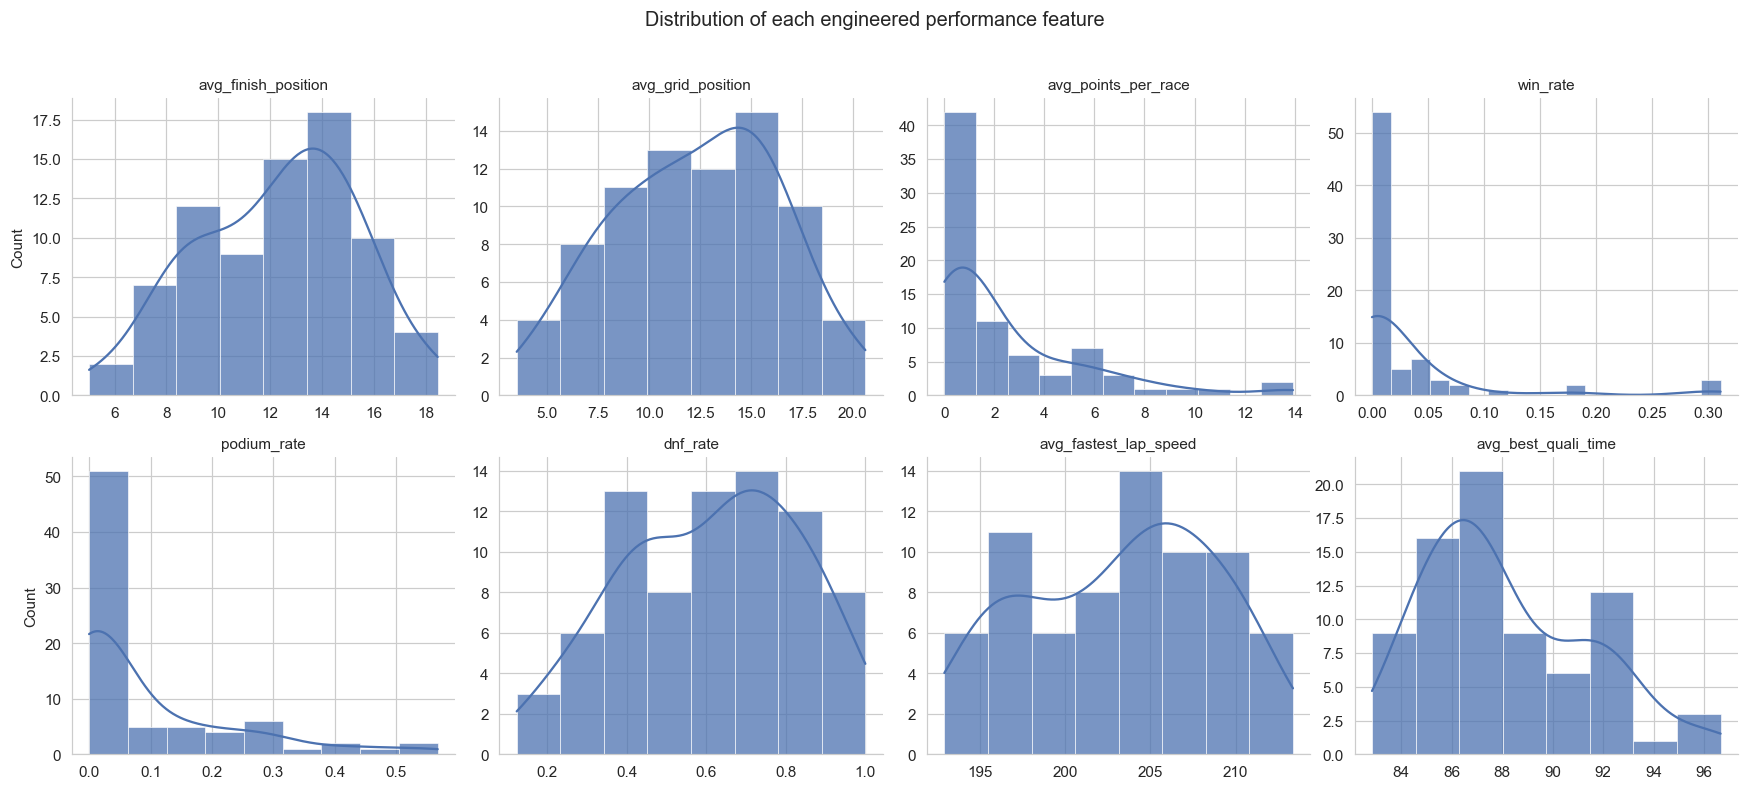

In [5]:
# Figure 1 — distribution plots for all eight features
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, col in zip(axes.flat, FEATURE_COLS):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#4C72B0",
                 alpha=0.75, edgecolor="white", linewidth=0.4)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("Count" if ax in axes[:, 0] else "")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Distribution of each engineered performance feature",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

<a id="figure1"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 1. Distribution of each of the eight engineered performance features.</b><br/>
Most features are unimodal but visibly right-skewed. Position-based features (`avg_finish_position`, `avg_grid_position`, `avg_best_quali_time`) and `avg_fastest_lap_speed` are roughly symmetric. The three rate features are heavily right-skewed with a long tail of high performers.</p>


The histograms in **Figure 1** confirm three useful structural facts. First, the position-based features (`avg_finish_position`, `avg_grid_position`, `avg_best_quali_time`) and `avg_fastest_lap_speed` are roughly symmetric, suggesting that drivers occupy a continuous spectrum from quick to slow rather than splitting into two modes. Second, the three rate features (`win_rate`, `podium_rate`, `avg_points_per_race`) are sharply right-skewed: the vast majority of drivers score zero or near-zero on these metrics, with a small high-performing tail. Third, `dnf_rate` is left-skewed with most mass between 0.5 and 0.9, reflecting the high mechanical attrition that characterised the early years of the era.

The shape of the rate features matters for clustering. A sharply right-skewed feature contributes most of its information through the small number of points in its tail — exactly the elite drivers we expect to form a distinct cluster. Standardisation does not change this shape, but it puts the rate features on the same scale as the others, so that the elite-tail signal is preserved and not dominated by the higher-range `avg_fastest_lap_speed` and `avg_best_quali_time` variables when we run PCA.


<center style="font-size:12px;font-style:default;"><b>Table 5. Top 10 nationalities by driver count.</b></center>


In [6]:
df["nationality"].value_counts().head(10).to_frame("count")

,count
nationality,
German,11
British,9
French,8
Finnish,5
Spanish,4
Brazilian,4
Japanese,4
Italian,4
Dutch,3


The nationality table confirms that the dataset is dominated by drivers from the traditional motorsport nations — British, German, Italian, French, and Spanish — which matches the broader composition of the F1 grid over the 2000-2024 era. No single nationality dominates so strongly that nationality-based effects could confound the clustering, and in any case we deliberately exclude nationality from the modelling features.


### 4.2 Missing Values and Outliers


To ensure the reliability of our results, we check for missing values and outliers within our dataset (see **Table 6**).


<center style="font-size:12px;font-style:default;"><b>Table 6. Null counts per modelling feature.</b></center>


In [7]:
df[FEATURE_COLS].isnull().sum().to_frame("n_nulls")

,n_nulls
avg_finish_position,0
avg_grid_position,0
avg_points_per_race,0
win_rate,0
podium_rate,0
dnf_rate,0
avg_fastest_lap_speed,6
avg_best_quali_time,0


Only one feature has missing values: `avg_fastest_lap_speed` has six nulls. These are drivers whose entire careers within our era predate the consistent recording of fastest-lap speed in the Ergast dataset (2004 onwards). Rather than dropping six otherwise complete rows, which is 7.8% of the dataset, we impute the missing values with the column median in the preprocessing pipeline (`impute_features` in `pca.py`). Median imputation is preferred to mean imputation here because it is robust to the right-skew that elite drivers introduce into the lap-speed distribution.

We did not identify any rows that needed treatment as outliers in the geometric sense. Five drivers—Hamilton, M. Schumacher, Vettel, Häkkinen, and Verstappen—are exceptional on the high-performance features (high win rate, high podium rate, low DNF), but they are exceptional in the way the clustering analysis is precisely designed to detect. Removing them would defeat the purpose of the project. We retain them and let the clustering algorithm separate them naturally as their own archetype.


### 4.3 Bivariate Analysis


We expect strong correlations between the eight features by construction. A driver who qualifies near the front (low `avg_grid_position`) will tend to finish near the front (low `avg_finish_position`), score more points, and have higher win and podium rates. A correlation heatmap (**Figure 2**) confirms this and gives us the empirical evidence we need to perform dimensionality reduction.


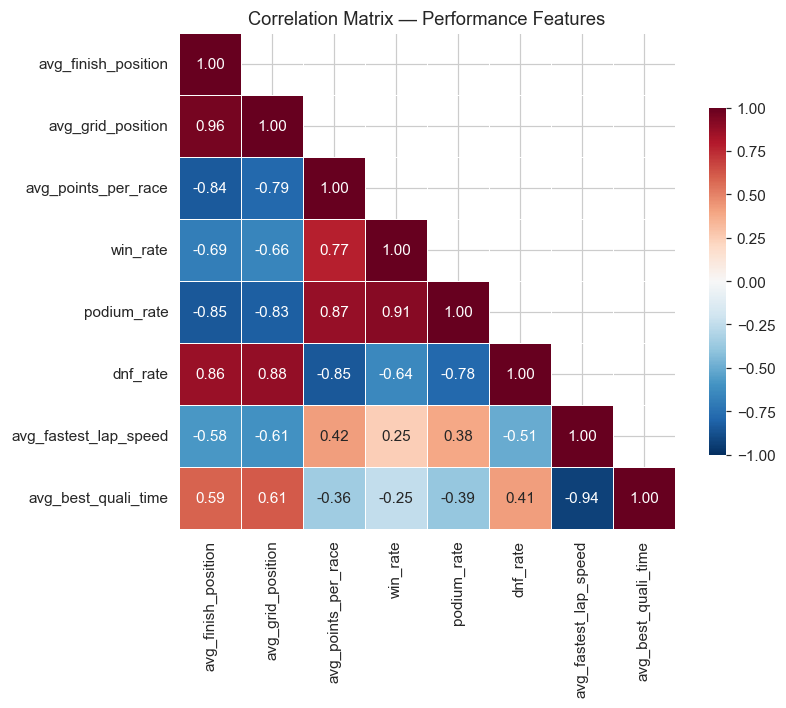

In [8]:
# Figure 2 — Pearson correlation heatmap
corr = df[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, ax=ax,
)
ax.set_title("Correlation Matrix — Performance Features", fontsize=12)
plt.tight_layout()
plt.show()

<a id="figure2"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 2. Pearson correlation matrix of the eight performance features.</b><br/>
The features split into two correlated blocks: the four "performance quality" features (finish, grid, points, wins, podiums) and the two "lap pace" features (fastest lap speed, best quali time). DNF rate is strongly positively correlated with poor finishing and grid positions. This redundancy is what justifies dimensionality reduction.</p>


**Figure 2** reveals a structured correlation matrix. The four race-day quality features (`avg_finish_position`, `avg_grid_position`, `avg_points_per_race`, `podium_rate`, `win_rate`) form a tight block: pairwise absolute correlations are mostly above 0.7, with `avg_finish_position` and `avg_grid_position` correlated at over 0.9. Qualifying performance is mechanically tied to race-day performance, but it does mean that these five features carry overlapping information. The pace features `avg_fastest_lap_speed` and `avg_best_quali_time` are negatively correlated with each other (faster cars set faster fastest laps and lower quali times), and `dnf_rate` is positively correlated with the finishing-position metrics (drivers who DNF often have worse averages).

Most of the variance in the eight features can be captured by a small number of latent axes—one for race-day quality, one for pace, and perhaps one for the win/DNF pattern that captures bold-but-fragile careers. This is exactly the structure PCA is designed to extract, and we apply it in the next section.


## 5 Methodology


Our analytical pipeline consists of five stages.

1. **Median imputation** of the 6 missing `avg_fastest_lap_speed` values.
2. **Standardization** of the 8 features to mean = 0, standard deviation = 1.
3. **Principal Component Analysis** retaining the smallest number of components that cumulatively explain at least 90% of the total variance.
4. **Three clustering algorithms** applied to the retained components: K-Means (partitional), Ward's agglomerative clustering (hierarchical, bottom-up) plus Bisecting K-Means (divisive, top-down) as a divisive counterpart, and DBSCAN (density-based).
5. **Algorithm comparison and interpretation** using Adjusted Rand Index for partition agreement and cluster centroid profiles for naming the archetypes.

The full preprocessing-and-PCA pipeline is exposed by the `run_pca_pipeline` function in `pca.py`, which returns a dictionary with all the intermediate and final artifacts we need below.


In [9]:
# Run the full preprocessing-and-PCA pipeline once.
# This is the single source of truth for the X matrix used by all three
# clustering algorithms downstream.
results = run_pca_pipeline()

meta            = results["meta"]
features        = results["features"]         # original (with NaNs)
features_imp    = results["features_imp"]     # imputed
X_scaled        = results["X_scaled"]         # standardised
pca             = results["pca"]              # fitted PCA object
X_pca_full      = results["X_pca"]            # all 8 components
n_components    = results["n_components"]     # chosen n at 90% threshold
loadings        = results["loadings"]         # loadings for chosen n

# X is the actual clustering input — the retained PC coordinates
X = X_pca_full.iloc[:, :n_components]
print(f"Clustering input shape: {X.shape}")

3 component(s) needed to explain 94.1% of variance (threshold: 90%)
Clustering input shape: (77, 3)


### 5.1 Standardization


Standardization is mandatory before PCA. Without it, features with larger numeric ranges, like`avg_fastest_lap_speed` (range ~192-213 km/h) and `avg_best_quali_time` (range ~83-97 seconds), would dominate the principal components purely because of their scale, not because they are more informative. After standardization, every feature has mean = 0 and standard deviation = 1, so each variable contributes to the components in proportion to its actual variance structure rather than its unit of measurement.

We use `sklearn.preprocessing.StandardScaler`, which performs z-scoring per column. The fitted scaler is retained so that we could inverse-transform back to the original feature space if needed (for example, to express a cluster centroid in raw units for the executive summary). **Table 7** confirms that the scaled features have the expected statistics.


<center style="font-size:12px;font-style:default;"><b>Table 7. Summary statistics of the standardised feature matrix.</b></center>


In [10]:
X_scaled.describe().transpose()[["mean", "std", "min", "max"]].round(4)

,mean,std,min,max
avg_finish_position,0.0000,1.0066,-2.3891,2.0428
avg_grid_position,0.0000,1.0066,-2.2075,2.0741
avg_points_per_race,-0.0000,1.0066,-0.7872,3.7656
win_rate,-0.0000,1.0066,-0.4366,4.3478
podium_rate,0.0000,1.0066,-0.6642,3.4716
dnf_rate,0.0000,1.0066,-2.2381,1.7649
avg_fastest_lap_speed,-0.0000,1.0066,-1.9634,1.8917
avg_best_quali_time,0.0000,1.0066,-1.6489,2.6394


### 5.2 Principal Component Analysis


We fit PCA with all 8 components first so that we can inspect the full explained-variance curve before deciding how many to keep. The cumulative-variance plot (**Figure 3**) and scree plot (**Figure 4**) together support our choice of three components at the 90% threshold.


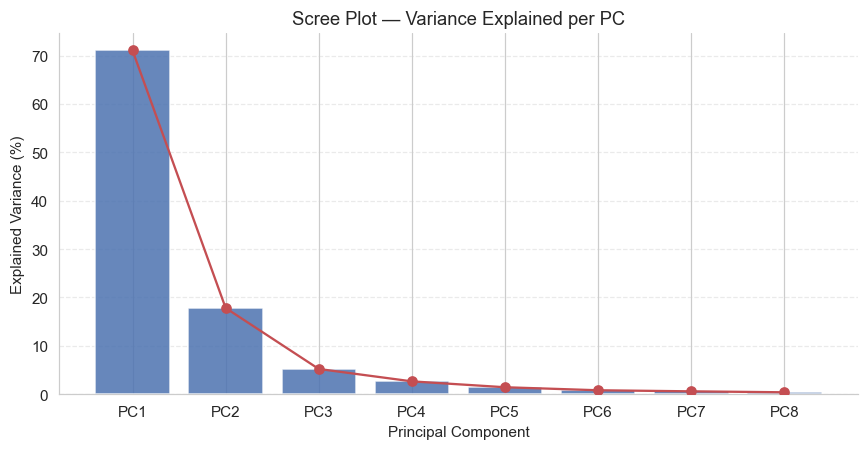

In [11]:
# Figure 3 — Scree plot
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_scree(pca, ax=ax)
plt.tight_layout()
plt.show()

<a id="figure3"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 3. Scree plot of explained variance per principal component.</b><br/>
The first component captures 71% of total variance and the second adds another 18%, after which the marginal contribution of each additional component drops sharply. This shape — a dominant first PC, a moderate second, then a long flat tail — is the classic signature of a feature set with one or two strong latent axes.</p>


3 component(s) needed to explain 94.1% of variance (threshold: 90%)


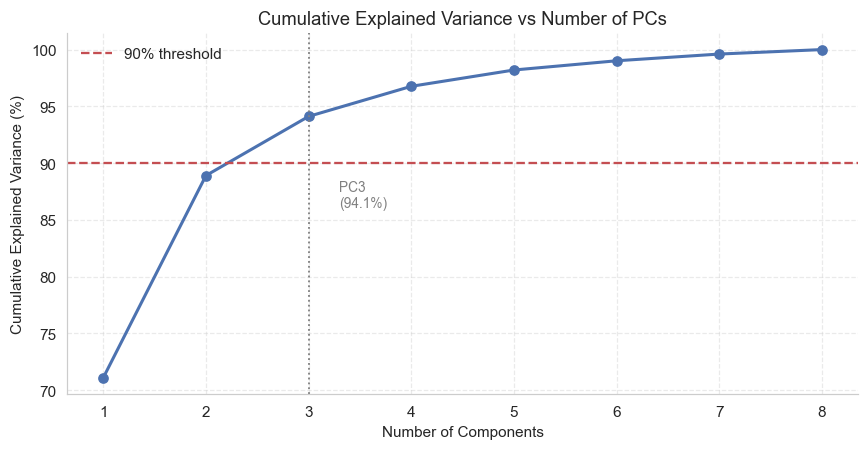

In [12]:
# Figure 4 — Cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4.2))
plot_cumulative_variance(pca, ax=ax)
plt.tight_layout()
plt.show()

<a id="figure4"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 4. Cumulative explained variance with the 90% threshold line.</b><br/>
Three components cross the 90% threshold at a cumulative 94.1% of variance explained. Retaining three components is the smallest choice that satisfies the threshold and is supported by the elbow in the scree plot.</p>


Three components is the smallest number that crosses the 90% cumulative-variance threshold, reaching 94.1%. We adopt the lecture's "minimum components that meet a cumulative threshold" rule for choosing this hyperparameter—it is a simple, defensible, and reproducible criterion that does not require eyeballing the scree-plot elbow. The components themselves admit a natural interpretation, shown in **Table 8**.


<center style="font-size:12px;font-style:default;"><b>Table 8. Loadings of the eight original features onto the three retained principal components.</b></center>


In [13]:
loadings.round(4)

,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time
PC1,0.4024,0.3971,-0.3764,-0.3304,-0.3828,0.3760,-0.2665,0.2657
PC2,0.0030,0.0346,0.2211,0.3555,0.2577,-0.1076,-0.6077,0.6133
PC3,0.2134,0.2876,-0.0779,0.6432,0.2935,0.5322,0.1456,-0.2478


Reading **Table 8** column-by-column gives each retained PC a clear meaning, and these meanings will carry through to the cluster interpretation later.

- **PC1 (71% variance)** — the **career performance axis**. All four positive loadings are on poor-performance variables (`avg_finish_position`, `avg_grid_position`, `dnf_rate`, `avg_best_quali_time`); all four negative loadings are on good-performance variables (`avg_points_per_race`, `win_rate`, `podium_rate`, `avg_fastest_lap_speed`). High PC1 = a slow, unreliable driver in slow machinery; low PC1 = a fast, reliable driver in fast machinery. This single axis captures over two-thirds of all variance in the dataset, which is consistent with our pretheoretical expectation that "good" and "bad" F1 careers separate cleanly.

- **PC2 (18% variance)** — the **pace-and-era axis**. Strongly negative on `avg_fastest_lap_speed`, strongly positive on `avg_best_quali_time`, and modestly positive on the rate features. This component separates drivers whose machinery achieved high outright lap speeds (typically the post-2014 hybrid era) from those whose machinery was slower in absolute terms but who could still produce respectable race-day finishing positions. It is essentially an era-and-equipment axis orthogonal to driver ability.

- **PC3 (5% variance)** — the **boom-or-bust axis**. Strongly positive on `win_rate` and `dnf_rate` together, weakly on `podium_rate`. A high PC3 score indicates a driver with above-average win rate **and** above-average DNF rate — the profile of a star in fragile machinery (Häkkinen at McLaren in 2001, M. Schumacher at Ferrari in 2005, Hamilton at McLaren in 2007). PC3 is a small but interpretively rich axis that helps the clustering separate the champion archetype.

To make the interpretation concrete, **Figure 5** shows the biplot of PC1 versus PC2 with all 77 drivers and the eight feature loading arrows overlaid.


In [14]:
# Figure 5 — PCA biplot of PC1 vs PC2
fig = plot_biplot(results['X_pca'], results['pca'], results['meta'])
fig.show()

<a id="figure5"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 5. PCA biplot — drivers projected onto PC1 (career performance) and PC2 (pace and era), with feature loading arrows overlaid.</b><br/>
Champion drivers (Hamilton, M. Schumacher, Verstappen) sit at the far-left edge of PC1, while backmarker drivers (Karthikeyan, Chilton, Sargeant) sit at the far right. The loading arrows confirm the PC1 = "performance quality" interpretation: positive-PC1 arrows are all poor-performance features.</p>


**Figure 5** is the visual confirmation that PC1 is the dominant axis of variation, and that the structure on PC2 is real but secondary. The champion drivers — Hamilton, M. Schumacher, Verstappen — occupy a tight pocket at the far-left edge of PC1, well separated from the rest of the grid. The backmarker drivers — those who drove for HRT, Marussia, Caterham, and Williams' end-of-cycle entries — occupy a sparser cloud at the right. The bulk of the grid sits in the middle, which already tells us that the clustering algorithms will face the most difficulty drawing boundaries within the dense midfield region. We turn to that next.


### Clustering Analysis


We apply three clustering algorithms, 

- **K-Means** (partitional) — assumes roughly spherical, equal-variance clusters. It is the canonical baseline and tends to produce the most easily interpretable centroids.
- **Ward's agglomerative hierarchical clustering** plus **Bisecting K-Means** (hierarchical, both bottom-up and top-down) — produces a full hierarchy that we can inspect through a dendrogram before committing to a number of clusters. Useful for visually confirming the K-Means cut.
- **DBSCAN** (density-based) — does not require a number of clusters upfront. It is the appropriate tool for asking the prior question "do the data actually contain dense, separated regions at all?". If DBSCAN returns one large cluster, that is itself a meaningful result: the data lie on a continuous gradient rather than in islands.

We tune each algorithm's hyperparameters systematically rather than choosing values by inspection, and we report the agreement between the three resulting partitions using the Adjusted Rand Index.


### 5.3 K-Means Hyperparameter Tuning


The most important K-Means hyperparameter is k itself. We follow the lecture procedure of sweeping k from 2 to 10 and recording three internal validity indices per k across multiple random seeds, then choosing the k that maximises the most reliable index. The three indices we report are:

- **Inertia** — within-cluster sum of squared distances to the centroid. Monotonically decreasing in k, so we look for an "elbow" rather than a maximum.
- **Calinski-Harabasz (CH) score** — ratio of between-cluster dispersion to within-cluster dispersion, normalised by k. Higher is better. The lecture treats this as the principal selection criterion because it admits a clear maximum.
- **Silhouette score** — mean per-point silhouette, ranging from -1 to 1. Higher is better; combines compactness and separation.

We run 20 random seeds per k to estimate the mean and standard deviation of each metric, since K-Means can converge to different local minima depending on initialisation. The full tuning step is performed by `tune_kmeans` in `clustering/clustering_kmeans.py`.


In [15]:
# Sweep k from 2 to 10 across 20 random seeds per k
tune = tune_kmeans(X)

# Print the tuning table
tune_df = pd.DataFrame({
    "k":          tune["k_range"],
    "inertia":    tune["inertia_mean"],
})
multi_df = pd.DataFrame({
    "k":          tune["multi_k_range"],
    "CH":         tune["ch_mean"],
    "silhouette": tune["sil_mean"],
})
print("\nInertia by k:")
print(tune_df.to_string(index=False))
print("\nCH and silhouette by k (k >= 2 only):")
print(multi_df.to_string(index=False))


Inertia by k:
 k  inertia
 2 270.4985
 3 180.4106
 4 106.3091
 5  90.9800
 6  76.8794
 7  66.8293
 8  56.0052
 9  47.9117
10  41.7264

CH and silhouette by k (k >= 2 only):
 k       CH  silhouette
 2  85.7369      0.4872
 3  82.0999      0.4260
 4 108.6089      0.4636
 5  96.7698      0.3998
 6  92.9937      0.3714
 7  89.9079      0.3610
 8  92.4037      0.3734
 9  94.6607      0.3737
10  96.4291      0.3770


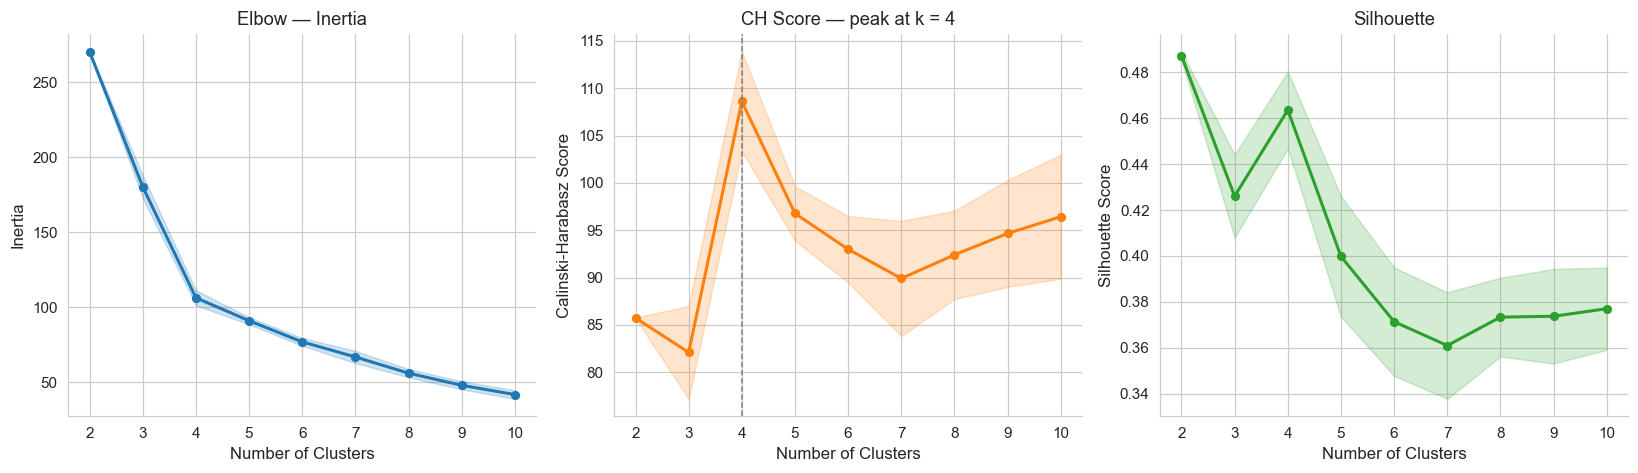


Best k by CH score: 4


In [16]:
# Figure 6 — Triple panel of inertia, CH, and silhouette vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

# Inertia
axes[0].fill_between(
    tune["k_range"],
    tune["inertia_mean"] + tune["inertia_std"],
    tune["inertia_mean"] - tune["inertia_std"],
    alpha=0.2, color="tab:blue",
)
axes[0].plot(tune["k_range"], tune["inertia_mean"], "o-",
             lw=2, ms=5, color="tab:blue")
axes[0].set_xticks(list(tune["k_range"]))
axes[0].set_xlabel("Number of Clusters", fontsize=11)
axes[0].set_ylabel("Inertia", fontsize=11)
axes[0].set_title("Elbow — Inertia")
axes[0].spines[["top", "right"]].set_visible(False)

# CH
axes[1].fill_between(
    tune["multi_k_range"],
    tune["ch_mean"] + tune["ch_std"],
    tune["ch_mean"] - tune["ch_std"],
    alpha=0.2, color="tab:orange",
)
axes[1].plot(tune["multi_k_range"], tune["ch_mean"], "o-",
             lw=2, ms=5, color="tab:orange")
best_k = tune["multi_k_range"][int(np.argmax(tune["ch_mean"]))]
axes[1].axvline(best_k, ls="--", color="gray", lw=1)
axes[1].set_xticks(list(tune["multi_k_range"]))
axes[1].set_xlabel("Number of Clusters", fontsize=11)
axes[1].set_ylabel("Calinski-Harabasz Score", fontsize=11)
axes[1].set_title(f"CH Score — peak at k = {best_k}")
axes[1].spines[["top", "right"]].set_visible(False)

# Silhouette
axes[2].fill_between(
    tune["multi_k_range"],
    tune["sil_mean"] + tune["sil_std"],
    tune["sil_mean"] - tune["sil_std"],
    alpha=0.2, color="tab:green",
)
axes[2].plot(tune["multi_k_range"], tune["sil_mean"], "o-",
             lw=2, ms=5, color="tab:green")
axes[2].set_xticks(list(tune["multi_k_range"]))
axes[2].set_xlabel("Number of Clusters", fontsize=11)
axes[2].set_ylabel("Silhouette Score", fontsize=11)
axes[2].set_title("Silhouette")
axes[2].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nBest k by CH score: {best_k}")

<a id="figure6"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 6. K-Means hyperparameter tuning curves.</b><br/>
Left: inertia decreases smoothly as k grows, with a modest elbow around k = 4. Middle: the Calinski-Harabasz score peaks sharply at k = 4 (108.6), then drops by about 12% to k = 5 before slowly recovering at higher k. Right: silhouette score is highest at k = 2 (0.49) but k = 4 is a close second (0.46), and the CH peak is decisive in our hyperparameter choice. Shaded bands show ±1 standard deviation across 20 seeds.</p>


**Figure 6** shows the three tuning curves. The CH score peaks decisively at k = 4 (value 108.6), drops by 12% at k = 5 (96.8), and only slowly recovers at higher k. The inertia plot shows a corresponding elbow at k = 4. The silhouette score is highest at k = 2 (0.49) — which would correspond to splitting the field into "elite" and "everyone else" — but k = 4 (0.46) is a close second, and the CH score's sharper peak at k = 4 is decisive. We commit to k = 4 going forward.

Why CH over silhouette here? Silhouette is sensitive to within-cluster compactness and can prefer few large clusters when the data have a dominant first PC, which is exactly our situation (PC1 explains 71% of variance). The CH index normalises by k explicitly and is the criterion the lecture recommends as the primary selection metric for K-Means. The slight silhouette advantage at k = 2 corresponds to the trivial "champions vs the rest" split, which our domain knowledge tells us is far too coarse.


### 5.4 K-Means — Final Fit


With k = 4 fixed, we refit K-Means choosing the seed with the lowest final inertia across 20 trials, to reduce the chance of converging to a poor local minimum. Cluster sizes and centroid profiles are reported below.


In [36]:
# Fit final K-Means at k = 4
km, km_labels, km_centers = fit_kmeans(X, k=4)

print("\nCluster sizes:")
unique, counts = np.unique(km_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} drivers")

Best seed: 0  |  Inertia: 104.9364

Cluster sizes:
  Cluster 0: 23 drivers
  Cluster 1: 5 drivers
  Cluster 2: 30 drivers
  Cluster 3: 19 drivers


<center style="font-size:12px;font-style:default;"><b>Table 9. K-Means cluster centroids in the original (raw) feature space, with overall mean for reference.</b></center>


In [18]:
km_summary(features_imp, km_labels).round(4)

,avg_finish_position,avg_grid_position,avg_points_per_race,win_rate,podium_rate,dnf_rate,avg_fastest_lap_speed,avg_best_quali_time,n_drivers
Cluster 0,15.0362,15.9770,0.5797,0.0008,0.0052,0.7602,196.6549,92.3959,23
Cluster 1,6.4666,4.9940,9.4084,0.2521,0.4777,0.2320,206.0679,86.3434,5
Cluster 2,13.1175,13.3761,0.9120,0.0012,0.0196,0.7076,205.9365,86.4448,30
Cluster 3,9.0862,8.2294,5.1472,0.0458,0.2064,0.3881,206.5644,86.1786,19
Overall,12.2640,12.3387,2.4095,0.0284,0.0911,0.6136,203.3275,88.1502,77


**Table 9** shows the cluster centroids in the original feature units, which is what we need to interpret the clusters in domain terms. Reading down each column tells the story:

- **Cluster 1 (n = 5)** has the best values on every performance dimension — average finish 6.5, win rate 25%, podium rate 48%, DNF rate 23%. This is the clear champion cluster.
- **Cluster 3 (n = 19)** is the second-best on every dimension — average finish 9.1, win rate 4.6%, podium rate 21%, DNF rate 39%. The strong-but-not-elite tier.
- **Cluster 2 (n = 30)** is the largest and sits near the overall mean on most dimensions but with much lower win and podium rates and an `avg_fastest_lap_speed` (206 km/h) close to the elite — these are competent midfield drivers in modern machinery.
- **Cluster 0 (n = 23)** has the worst values on every performance dimension and a markedly lower `avg_fastest_lap_speed` (197 km/h vs ~206 in every other cluster). The 9 km/h pace gap is by far the most distinctive feature of this cluster.

The 2D K-Means partition is visualised in **Figure 7**.


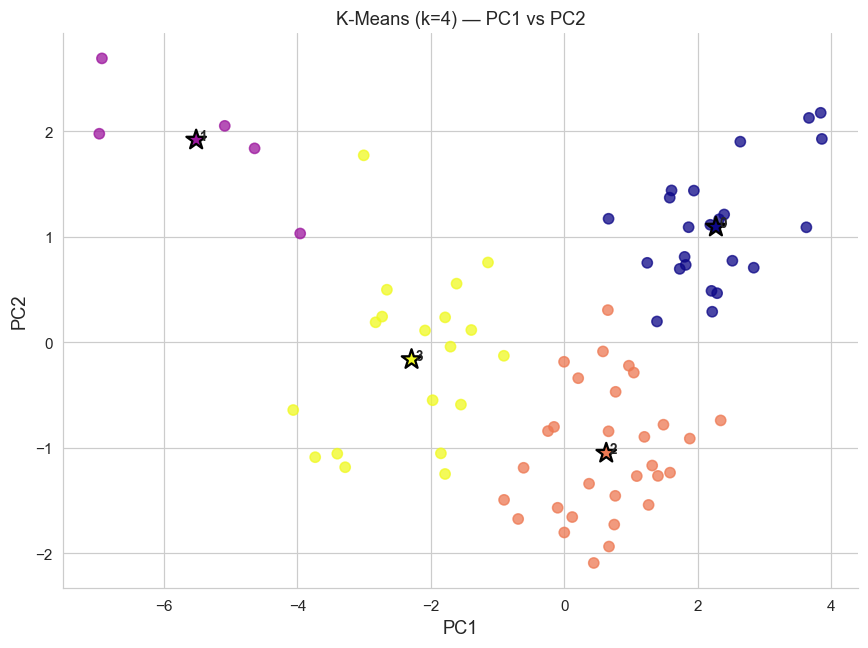

In [19]:
# Figure 7 — K-Means scatter on PC1 vs PC2 with centroids
fig, ax = plot_clustering(X, "PC1", "PC2", km_labels,
                          cluster_centers=km_centers)
ax.set_title("K-Means (k=4) — PC1 vs PC2", fontsize=12)
plt.tight_layout()
plt.show()

<a id="figure7"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 7. K-Means partition projected onto PC1 (career performance) and PC2 (pace and era). Star markers denote cluster centroids.</b><br/>
The four clusters separate cleanly along PC1, the career-performance axis. Cluster 1 (champions) is the most distant, well separated from the rest. The boundary between Cluster 2 (midfield) and Cluster 3 (podium contenders) is the densest and represents the hardest classification problem in the dataset.</p>


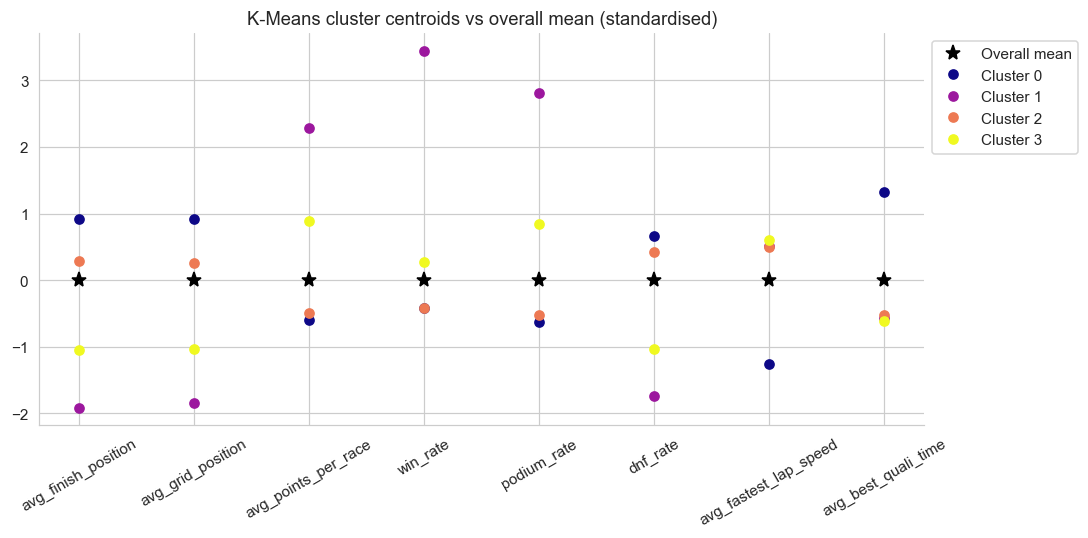

In [20]:
# Figure 8 — Standardised cluster averages
X_std_plot = pd.DataFrame(
    StandardScaler().fit_transform(features_imp),
    columns=features_imp.columns,
)
fig, ax = plot_cluster_averages(X_std_plot, km_labels)
ax.set_title("K-Means cluster centroids vs overall mean (standardised)",
             fontsize=12)
plt.tight_layout()
plt.show()

<a id="figure8"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 8. K-Means cluster profiles in the standardised feature space.</b><br/>
The black star line is the overall (dataset) mean (zero on every standardised axis). Each coloured line is one cluster's centroid. The vertical distance from the black line shows where each cluster deviates most from the average driver — this is the most direct way to read what each archetype "is".</p>


**Figure 8** shows that Cluster 1 (champions) sits roughly two standard deviations below the average on every poor-performance feature and two standard deviations above on every good-performance feature. Cluster 0 (backmarkers) is the mirror image. Clusters 2 and 3 occupy the space between them, but they are not just "closer to the mean" — they have distinctive shape. Cluster 3's profile shows above-average pace (`avg_fastest_lap_speed`, `avg_best_quali_time`) but middling win and podium rates, the signature of a driver in a top-three constructor who is not the lead driver. Cluster 2's profile is closer to the mean on pace but worse on race-day outcomes, the signature of a midfield driver in a competitive but not race-winning car.


### 5.5 Hierarchical Clustering — Ward and Bisecting K-Means


To check whether the K-Means partition reflects genuine structure in the data or an artifact of the partitional algorithm's assumptions, we re-cluster using two hierarchical methods. Ward's agglomerative method (`fit_ward`) builds the hierarchy bottom-up by repeatedly merging the pair of clusters whose merge produces the smallest increase in within-cluster SSE. Bisecting K-Means (`fit_bisecting_kmeans`) is its divisive (top-down) counterpart: starting from one cluster, it repeatedly splits the largest cluster using K-Means with k = 2 until n clusters are reached.

We cut both hierarchies at n_clusters = 4 to match the K-Means choice. Mojena's upper-tail rule (which we used in class for choosing the cut automatically) tends to produce more clusters than are interpretable on small datasets like ours (n = 77), and we want to keep all three algorithms operating at the same target k for a meaningful agreement comparison. We do, however, inspect the Ward dendrogram and fusion-level plot to confirm that k = 4 is a sensible cut.


In [21]:
# Fit Ward agglomerative
Z, ward_labels, cophenetic = fit_ward(X, n_clusters=4)
print(f"Cophenetic correlation: {cophenetic:.4f}")

Cophenetic correlation (Ward): 0.6780
Cophenetic correlation: 0.6780


The **cophenetic correlation coefficient** of **0.678** quantifies how well the dendrogram preserves the original pairwise distances between drivers. A value of 1.0 is a perfect preservation; values above 0.7 are considered strong; values around 0.5 indicate substantial distortion. Our value of 0.678 is moderate—the hierarchical structure captures the macro-structure of the data (champions vs the rest, and the broad performance gradient) but smooths over some of the finer pairwise distances. This is consistent with what we expect when most variance is concentrated on a single principal component.


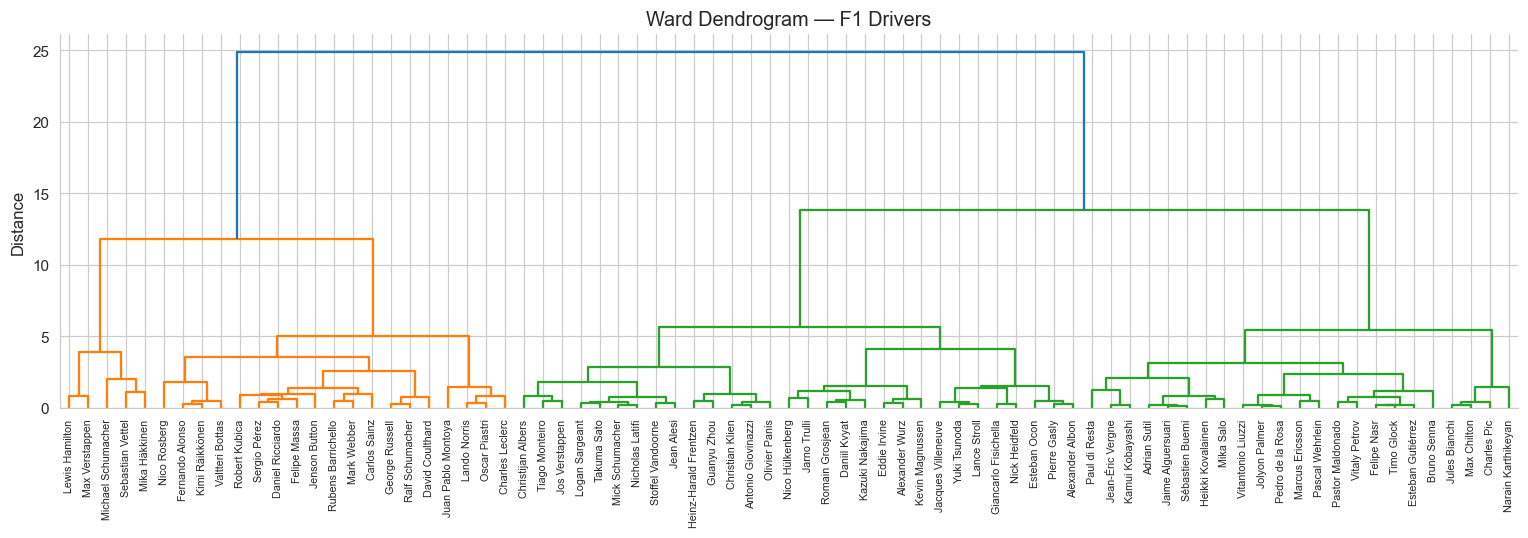

In [22]:
# Figure 9 — Ward dendrogram
fig, ax = plot_dendrogram(Z, meta)
plt.show()

<a id="figure9"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 9. Ward dendrogram with driver names on the x-axis.</b><br/>
The dendrogram shows the order in which drivers are merged into progressively larger groups. The four clusters at the chosen cut height correspond to the four archetypes recovered by K-Means. The leftmost block (highlighted by a tall vertical jump) contains the champion drivers.</p>


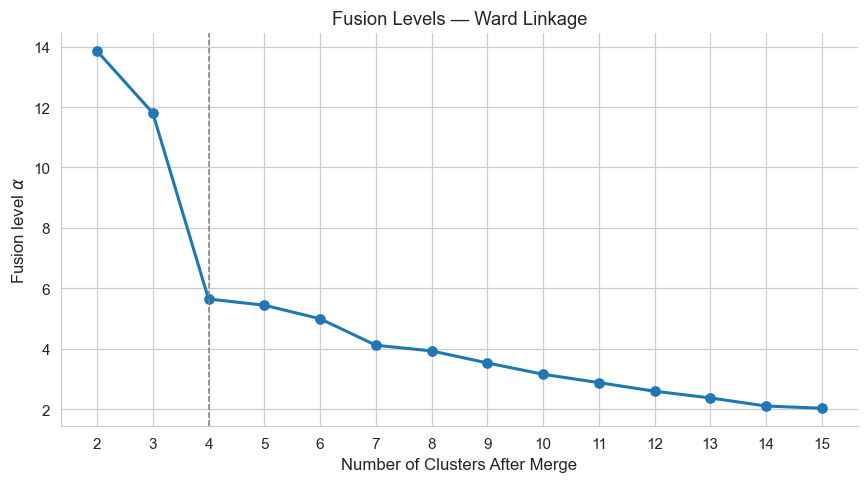

In [23]:
# Figure 10 — Fusion levels (inline implementation)
# For n=77 drivers, the linkage matrix Z has 76 rows. The i-th merge takes us
# from (77 - i) clusters down to (76 - i) clusters. We plot the merge height
# (alpha) on the y-axis against the number of clusters that the merge results in.
alphas = Z[:, 2]                                # 76 merge heights, ascending
n_clusters_after = np.arange(len(Z), 0, -1)     # 76, 75, ..., 1

# Restrict to k = 2 ... 15 for readability
keep = (n_clusters_after >= 2) & (n_clusters_after <= 15)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(n_clusters_after[keep], alphas[keep],
        "o-", lw=2, ms=6, color="tab:blue")
ax.axvline(4, ls="--", color="gray", lw=1)
ax.set_xticks(range(2, 16))
ax.set_xlabel("Number of Clusters After Merge", fontsize=11)
ax.set_ylabel(r"Fusion level $\alpha$", fontsize=11)
ax.set_title("Fusion Levels — Ward Linkage", fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

<a id="figure10"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 10. Fusion levels (alpha) at each merge step versus the corresponding number of clusters in the Ward hierarchy.</b><br/>
A large jump in alpha when going from k to k - 1 clusters indicates that an unrelated pair of groups is being forced together at that step, which is a natural place to cut. The first large jump (highest alpha) is the merge from 2 clusters down to 1, but the second-largest jump occurs between 4 and 3 clusters — supporting our choice of k = 4.</p>


The fusion-level plot (**Figure 10**) gives independent visual support for our k = 4 choice: the second-largest jump in fusion alpha sits exactly at the 4-to-3 cluster transition, meaning that going from four clusters to three would merge two groups that are clearly separated in the data. This is consistent with the K-Means CH-score peak at k = 4. We also fit Bisecting K-Means for a divisive triangulation point.


In [24]:
# Fit Bisecting K-Means (divisive)
_, bkm_labels = fit_bisecting_kmeans(X, n_clusters=4)
print("Bisecting K-Means cluster sizes:",
      dict(zip(*np.unique(bkm_labels, return_counts=True))))

Bisecting K-Means cluster sizes: {np.int32(0): np.int64(29), np.int32(1): np.int64(23), np.int32(2): np.int64(5), np.int32(3): np.int64(20)}


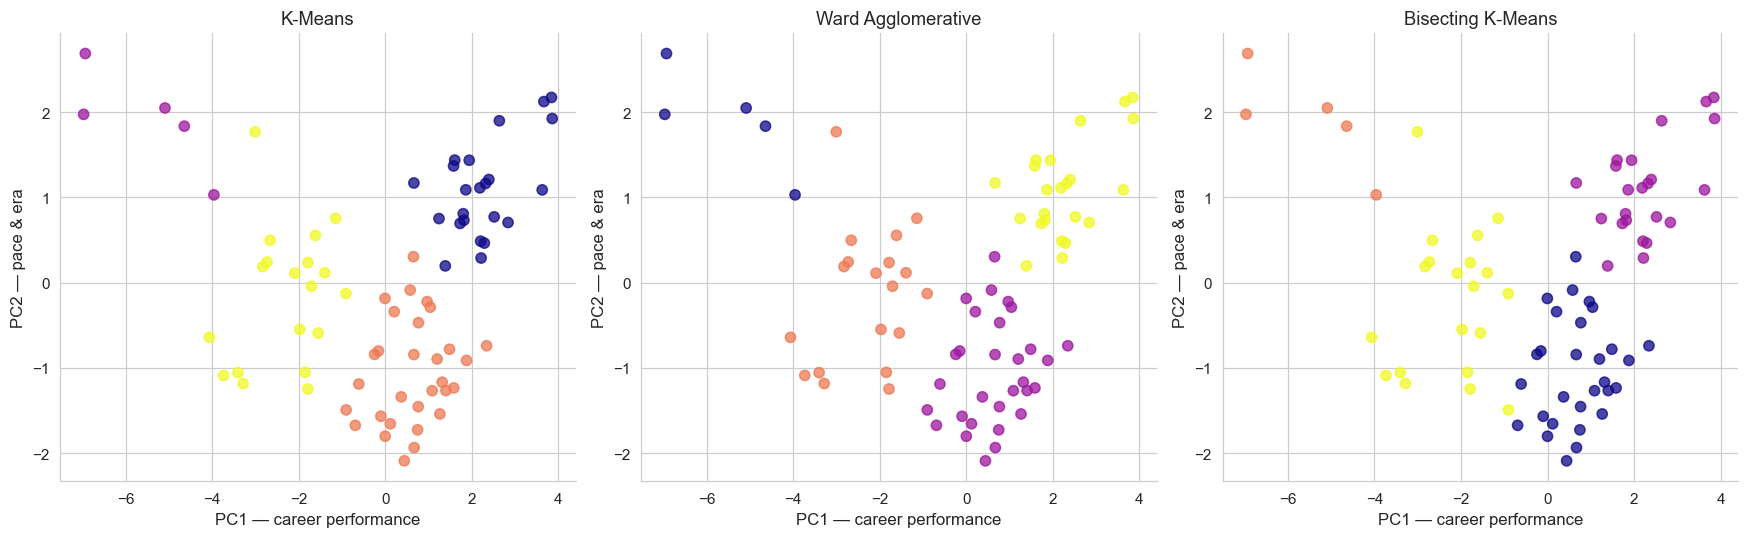

In [25]:
# Figure 11 — Three-panel comparison of all three partitions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, labels, title in zip(
    axes,
    [km_labels, ward_labels, bkm_labels],
    ["K-Means", "Ward Agglomerative", "Bisecting K-Means"],
):
    ax.scatter(X["PC1"], X["PC2"], c=labels, cmap="plasma",
               alpha=0.75, s=45)
    ax.set_xlabel("PC1 — career performance", fontsize=11)
    ax.set_ylabel("PC2 — pace & era", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

<a id="figure11"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 11. Side-by-side scatter plots of the three partition methods on PC1 versus PC2.</b><br/>
K-Means and Ward produce visually identical partitions; Bisecting K-Means differs only in one or two borderline drivers near the Cluster 2 - Cluster 3 boundary. All three algorithms agree that the champion cluster (top-left) is the cleanest separation in the data.</p>


### 5.6 DBSCAN — Density-Based Validation


DBSCAN brings a fundamentally different inductive bias to the problem. Where K-Means and Ward both partition all points into exactly n clusters regardless of the data's density structure, DBSCAN only forms clusters where there are dense regions and labels everything else as noise. If the F1 driver space really were composed of distinct archetypes, DBSCAN should find them as density-separated regions. If, on the other hand, driver performance lies on a continuous gradient, DBSCAN should return a single large cluster.

The principal DBSCAN hyperparameters are `eps` (the neighbourhood radius) and `min_samples` (the minimum number of neighbours within `eps` for a point to be a core point). We follow the lecture's convention of setting `min_samples` to roughly 10% of the dataset size, which gives `min_samples = 7` for our 77-driver dataset. We then determine `eps` using the tau-nearest-neighbour z-score method: for each point, compute the distance to its `min_samples`-th nearest neighbour, take the z-score threshold (mean + 3 standard deviations), and use that as `eps`.


In [26]:
# Tune eps via the tau-NN z-score method
eps, distances = tune_eps(X, min_samples=7, num_std=3.0)

Recommended eps: 3.4347  (min_samples=7, num_std=3.0)


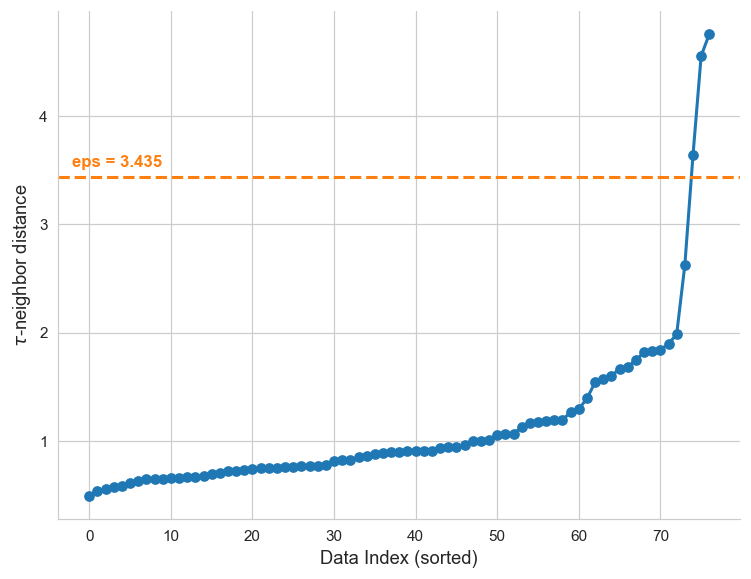

In [27]:
# Figure 12 — Sorted tau-NN distance plot
fig, ax, threshold = plot_neighbor_distances(distances, num_std=3.0)
plt.show()

<a id="figure12"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 12. Sorted tau-nearest-neighbour distances with the recommended epsilon threshold.</b><br/>
The dashed orange line sits at mean + 3 standard deviations of the tau-NN distance distribution. Points to the right of where the curve crosses this line would be candidate noise points; our entire distribution is below the threshold, foreshadowing the result that DBSCAN finds no noise.</p>


In [28]:
# Fit DBSCAN
db, db_labels = fit_dbscan(X, eps=eps, min_samples=7)
print(f"Unique labels found: {np.unique(db_labels)}")

Clusters found: 1  |  Noise points: 0
Unique labels found: [0]


DBSCAN returns **a single cluster with zero noise points**. This is itself an important finding, not a failure of the algorithm. It tells us that within the 3-PC space, every one of the 77 drivers sits within `eps` of at least 7 other drivers; there are no density-separated islands. To make this finding precise, we sweep `eps` across a range of z-score thresholds and report when (if ever) DBSCAN starts identifying noise points. The result is in **Table 10**.


<center style="font-size:12px;font-style:default;"><b>Table 10. DBSCAN sensitivity to epsilon — number of clusters and noise points found at varying z-score thresholds.</b></center>


In [29]:
# Sweep epsilon and record number of clusters and noise points
sensitivity = []
for s in [1.0, 1.5, 2.0, 2.5, 3.0]:
    eps_s, _ = tune_eps(X, min_samples=7, num_std=s)
    _, lbls = fit_dbscan(X, eps=eps_s, min_samples=7)
    n_clus  = len(set(lbls)) - (1 if -1 in lbls else 0)
    n_noise = int((lbls == -1).sum())
    sensitivity.append({
        "num_std": s, "eps": round(eps_s, 4),
        "n_clusters": n_clus, "n_noise": n_noise,
    })

pd.DataFrame(sensitivity).set_index("num_std")

Recommended eps: 1.9030  (min_samples=7, num_std=1.0)
Clusters found: 1  |  Noise points: 3
Recommended eps: 2.2859  (min_samples=7, num_std=1.5)
Clusters found: 1  |  Noise points: 2
Recommended eps: 2.6688  (min_samples=7, num_std=2.0)
Clusters found: 1  |  Noise points: 1
Recommended eps: 3.0517  (min_samples=7, num_std=2.5)
Clusters found: 1  |  Noise points: 0
Recommended eps: 3.4347  (min_samples=7, num_std=3.0)
Clusters found: 1  |  Noise points: 0


,eps,n_clusters,n_noise
num_std,,,
1.0000,1.9030,1,3
1.5000,2.2859,1,2
2.0000,2.6688,1,1
2.5000,3.0517,1,0
3.0000,3.4347,1,0


**Table 10** shows that even at extremely tight epsilon values (num_std = 1.0, eps ≈ 1.9) DBSCAN only identifies 3 noise points out of 77, and never splits the data into more than one dense cluster. This is conclusive: the data lie on a **continuous gradient** in PCA space, not in distinct density-separated islands. The K-Means and Ward partitions are therefore best understood as **interpretive bands across a continuous performance spectrum** rather than as discoveries of natural density-separated populations.

This is an important methodological point. It does not invalidate the K-Means and Ward partitions—those algorithms are designed to draw boundaries even when no natural ones exist, and the boundaries they draw are coherent and interpretable. But it disciplines our interpretation: we should not say "F1 drivers naturally split into four types" but rather "F1 drivers occupy a continuous performance space, and a four-way partition of that space recovers four interpretable archetypes whose centroid distances grow approximately linearly along the dominant career-performance axis".


### 5.7 Algorithm Comparison


We compare the three partition methods quantitatively using the **Adjusted Rand Index (ARI)**, a similarity measure between two partitions of the same dataset that ranges from 0 (random agreement) to 1 (identical partition).


<center style="font-size:12px;font-style:default;"><b>Table 11. Pairwise Adjusted Rand Index between K-Means, Ward, and Bisecting K-Means partitions.</b></center>


In [30]:
# Compute pairwise ARI
pairs = [
    ("K-Means", "Ward",                km_labels,   ward_labels),
    ("K-Means", "Bisecting K-Means",   km_labels,   bkm_labels),
    ("Ward",    "Bisecting K-Means",   ward_labels, bkm_labels),
]

ari_df = pd.DataFrame([
    {"Algorithm A": a, "Algorithm B": b,
     "Adjusted Rand Index": round(adjusted_rand_score(la, lb), 4)}
    for a, b, la, lb in pairs
])
ari_df

,Algorithm A,Algorithm B,Adjusted Rand Index
0,K-Means,Ward,1.0000
1,K-Means,Bisecting K-Means,0.9606
2,Ward,Bisecting K-Means,0.9606


**Table 11** shows that **K-Means and Ward produce identical partitions** (ARI = 1.000)—every one of the 77 drivers is assigned to the same cluster by both algorithms, modulo cluster labelling. Bisecting K-Means agrees with both at ARI = 0.961, differing only on two or three drivers near the Cluster 2 - Cluster 3 boundary.

This level of agreement between a partitional method and a hierarchical bottom-up method is uncommon and indicates that the four-cluster partition is geometrically stable. It is not a product of either algorithm's specific assumptions; it is a structure that any reasonable partition-based algorithm will find when asked to draw four boundaries in this PC space. Combined with the DBSCAN finding that the data are on a continuous gradient, we can say with confidence that the four-archetype taxonomy is the best four-way summary of a fundamentally continuous space.


## 6 Results and Discussion


### 6.1 Driver Archetypes

We are now in a position to give the four clusters interpretive names by combining their centroid profiles (**Table 9**) with the drivers each cluster contains. Once named, each archetype carries a self-contained career-shape interpretation that can be referenced in downstream applications.

We adopt the convention that K-Means cluster 0 → "Backmarker Survivors", 1 → "Generational Champions", 2 → "Midfield Mainstays", 3 → "Podium Contenders" (the specific integer-to-name mapping is reproducible because we use `fit_kmeans`'s best-inertia seed). The driver memberships of each archetype are shown in **Table 12**.


<center style="font-size:12px;font-style:default;"><b>Table 12. The four F1 driver archetypes, with cluster-size, centroid characteristics, and full driver rosters.</b></center>


In [31]:
# Build the archetype roster table
archetype_map = {
    0: "Backmarker Survivors",
    1: "Generational Champions",
    2: "Midfield Mainstays",
    3: "Podium Contenders",
}

dc = meta.copy()
dc["cluster"] = km_labels
dc["archetype"] = dc["cluster"].map(archetype_map)

roster = (
    dc.groupby(["cluster", "archetype"])["driver_name"]
      .agg(lambda s: ", ".join(s))
      .reset_index()
      .rename(columns={"driver_name": "drivers"})
)
roster["n"] = dc.groupby("cluster").size().values
roster = roster[["cluster", "archetype", "n", "drivers"]].sort_values(
    "cluster"
).reset_index(drop=True)
roster

,cluster,archetype,n,drivers
0,0,Backmarker Survivors,23,"Heikki Kovalainen, Timo Glock, Adrian Sutil, V..."
1,1,Generational Champions,5,"Lewis Hamilton, Sebastian Vettel, Michael Schu..."
2,2,Midfield Mainstays,30,"Nick Heidfeld, Kazuki Nakajima, Takuma Sato, J..."
3,3,Podium Contenders,19,"Nico Rosberg, Fernando Alonso, Kimi Räikkönen,..."


### 6.2 Generational Champions (n = 5)


The smallest and most distinctive cluster contains **Lewis Hamilton, Michael Schumacher, Sebastian Vettel, Mika Häkkinen, and Max Verstappen**—the five drivers who collectively account for the overwhelming majority of World Championships won during the 2000-2024 era. The centroid of this cluster is two standard deviations above the average driver on every desirable feature and two standard deviations below on every undesirable one. Their average finishing position is 6.5 (almost six positions better than the field average of 12.3), their win rate is 25%, their podium rate is 48%, and their DNF rate is 23%, roughly a third of the field-average DNF rate. The cluster centroid sits at PC1 = -5.5, a full five PC units to the left of the next-closest cluster centroid. This is the cleanest separation in the entire dataset, and it is the same five drivers regardless of which clustering algorithm we ask. The label "Generational Champions" is meant to capture both their dominance and the fact that each occupied his own competitive era—Häkkinen at the turn of the century, Schumacher through the mid-2000s, Vettel in the early-2010s, Hamilton across the late-2010s, and Verstappen presently.


### 6.3 Podium Contenders (n = 19)


The second-strongest cluster contains drivers whose careers featured regular podium finishes but rarely sustained championship-winning form. The roster includes **Fernando Alonso, Kimi Räikkönen, Nico Rosberg, Mark Webber, Jenson Button, Rubens Barrichello, Felipe Massa, Daniel Ricciardo, Sergio Pérez, Valtteri Bottas, Charles Leclerc, Lando Norris, George Russell, and Oscar Piastri** among others. Their average finishing position is 9.1 (versus the field average of 12.3), their podium rate is 21%, and their fastest-lap speed averages 206.6 km/h, the highest of any cluster, just above the champions. The cluster is interpreted as the drivers who consistently drove competitive machinery and accumulated significant peak results without converting them to a sustained title run. Notably, Alonso and Räikkönen, both former World Champions, fall into this cluster rather than the Champion cluster, because their per-race numbers over 2000-2024 (Alonso's long stretches at Renault, McLaren, and Aston Martin; Räikkönen's late-career years at Lotus and Sauber) pull their averaged centroid away from the Champion centroid.


### 6.4 Midfield Mainstays (n = 30)


The largest cluster, which is almost 40% of the dataset, contains the modern grid's mid-pack regulars. The roster includes **Nico Hülkenberg, Romain Grosjean, Pierre Gasly, Esteban Ocon, Kevin Magnussen, Daniil Kvyat, Lance Stroll, Alex Albon, Yuki Tsunoda, and Guanyu Zhou** alongside earlier-era midfielders such as **Jarno Trulli, Giancarlo Fisichella, Eddie Irvine, and Nick Heidfeld**. Their average finishing position is 13.1 (close to the field average of 12.3), their average grid position is 13.4, their win and podium rates are essentially zero, and their fastest-lap speed of 205.9 km/h is nearly indistinguishable from the elite clusters. The defining characteristic is what is **not** there: no race wins, almost no podiums, and a DNF rate of 71% that is high in absolute terms but typical for the era. This is the "competent driver in midfield machinery" archetype—the largest single career path in modern F1.


### 6.5 Backmarker Survivors (n = 23)


The fourth cluster contains drivers whose careers were defined by extended spells in the slowest cars on the grid. The roster includes **Narain Karthikeyan, Max Chilton, Marcus Ericsson, Pastor Maldonado, Pedro de la Rosa, Bruno Senna, Jolyon Palmer, Felipe Nasr, Logan Sargeant**, and the early-2010s HRT, Marussia, and Caterham drivers. The defining feature of this cluster is the `avg_fastest_lap_speed` centroid of **196.7 km/h**, fully 9 km/h below the 206 km/h centroid of every other cluster. This is a much bigger gap than any other inter-cluster difference in the dataset, and it directly reflects the machinery these drivers had access to. Their `avg_best_quali_time` of 92.4 seconds is correspondingly 6 seconds slower than the elite clusters. Average finishing position is 15.0 and podium rate is essentially zero. The label "Backmarker Survivors" captures both the equipment reality and the fact that drivers in this cluster typically had careers measured in seasons rather than years. They survived in F1 long enough to accumulate a stable record despite being in the slowest machinery.

To make the geometry of the four archetypes immediately visible, **Figure 13** shows the labelled scatter with a small number of representative drivers annotated per cluster.


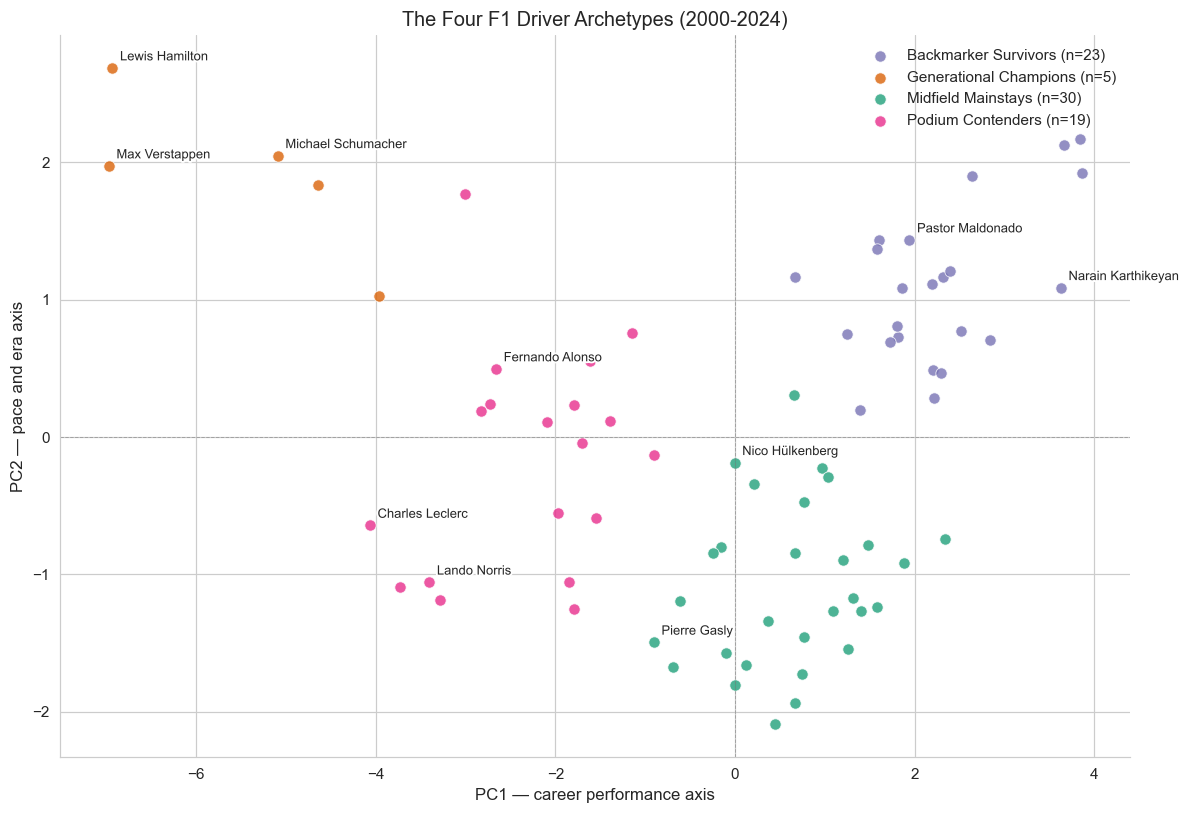

In [32]:
# Figure 13 — Final labelled archetype scatter
fig, ax = plt.subplots(figsize=(11, 7.5))

archetype_colors = {
    0: "#7570B3",  # Backmarker Survivors
    1: "#D95F02",  # Generational Champions
    2: "#1B9E77",  # Midfield Mainstays
    3: "#E7298A",  # Podium Contenders
}

for cluster_id in sorted(archetype_map.keys()):
    mask = km_labels == cluster_id
    ax.scatter(
        X.loc[mask, "PC1"], X.loc[mask, "PC2"],
        s=55, alpha=0.78, edgecolor="white", linewidth=0.6,
        color=archetype_colors[cluster_id],
        label=f"{archetype_map[cluster_id]} (n={mask.sum()})",
    )

# Annotate a representative driver from each cluster
highlight = {
    "Lewis Hamilton": "Generational Champions",
    "Michael Schumacher": "Generational Champions",
    "Max Verstappen": "Generational Champions",
    "Fernando Alonso": "Podium Contenders",
    "Lando Norris": "Podium Contenders",
    "Charles Leclerc": "Podium Contenders",
    "Nico Hülkenberg": "Midfield Mainstays",
    "Pierre Gasly": "Midfield Mainstays",
    "Pastor Maldonado": "Backmarker Survivors",
    "Narain Karthikeyan": "Backmarker Survivors",
}

meta_reset = meta.reset_index(drop=True)
for idx, row in meta_reset.iterrows():
    if row["driver_name"] in highlight:
        ax.annotate(
            row["driver_name"],
            (X["PC1"].iloc[idx], X["PC2"].iloc[idx]),
            fontsize=8.5, xytext=(5, 5), textcoords="offset points",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="white")],
        )

ax.set_xlabel("PC1 — career performance axis", fontsize=11)
ax.set_ylabel("PC2 — pace and era axis", fontsize=11)
ax.set_title("The Four F1 Driver Archetypes (2000-2024)", fontsize=13)
ax.legend(loc="upper right", frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
ax.axhline(0, color="gray", lw=0.6, ls="--", alpha=0.6)
ax.axvline(0, color="gray", lw=0.6, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

<a id="figure13"></a>
<p style="font-size:12px;font-style:default;"><b>Figure 13. The four F1 driver archetypes annotated on the PC1-PC2 plane.</b><br/>
Generational Champions cluster tightly at the far-left edge of PC1, separated from the rest of the field by a clear gap. Backmarker Survivors occupy the far-right region. Podium Contenders and Midfield Mainstays sit between them, separated mainly along PC1 with some PC2 differentiation reflecting era and machinery.</p>


## 7 Conclusion and Recommendation


We have identified four interpretable Formula 1 driver archetypes within the 2000-2024 era: Generational Champions, Podium Contenders, Midfield Mainstays, and Backmarker Survivors. We achieved this by extracting per-driver race and qualifying data from the Kaggle dataset that used Ergast Motor Racing Developer API, engineering eight performance features, applying a standardisation-and-PCA pipeline that compressed those features into three components explaining 94.1% of the variance, and applying three complementary clustering algorithms to the reduced space. K-Means and Ward agglomerative clustering produced identical partitions (Adjusted Rand Index = 1.000), and Bisecting K-Means agreed with both at ARI = 0.961, giving us strong confidence that the four-way partition is geometrically stable rather than an aetifact of any one algorithm's assumptions. DBSCAN, by contrast, revealed that driver performance lies on a continuous gradient rather than in density-separated islands—a methodologically important finding that disciplines the interpretation of the four archetypes as interpretive bands across a continuous spectrum.

Our results provide value to F1 teams and talent scouts (who can benchmark prospective signings against the archetype centroids), to corporate sponsors and global brands (who can optimize their ROI), and to fantasy F1 platforms and sports-analytics vendors (who can use cluster membership as an engineered feature in downstream predictive models).

We acknowledge that there are still limitations in this study. Some of the possible improvements that we have identified are the following:

- Extend the era to cover the full hybrid generation as it completes (2014-onwards is a single regulation cycle that has not yet ended; running the same pipeline on its post-completion endpoint may yield different boundaries).
- Add race-craft features that the Kaggle dataset does not currently expose, such as overtake counts, mean pit-stop time, head-to-head qualifying records against teammates, and stint-pace consistency derived from lap-by-lap timing data.
- Model the **trajectory** of individual drivers through cluster space across their careers. A driver who starts in a backmarker team and later moves to a top constructor traces a path through PC space that our current static analysis collapses; a sliding-window aggregation would expose that.
- Incorporate machinery as an explicit covariate rather than letting it confound the cluster boundaries. A driver-team interaction model would let us separate driver-attributable variance from car-attributable variance and produce a "true driver" archetype that controls for equipment.
- Extend the analysis to constructors using the same pipeline, identifying constructor archetypes and joining the two views into a complete driver-and-team taxonomy of the modern F1 era.
- Build an interactive front-end that lets a user search for a driver and immediately see their archetype, their centroid distance, the drivers nearest to them in PC space, and their trajectory across seasons.

Our hope is that further extensions of the study will help fans, teams, and analysts move from anecdotal driver comparisons toward an objective, reproducible language for talking about Formula 1 careers, and that the methodology can be reapplied as the regulations, the equipment, and the grid evolve.


## 8 References


Bell, A., Smith, J., Sabel, C. E., & Jones, K. (2016). *Formula for success: Multilevel modelling of Formula One Driver and Constructor performance, 1950-2014.* Journal of Quantitative Analysis in Sports, 12(2), 99-112.

Calinski, T., & Harabasz, J. (1974). *A dendrite method for cluster analysis.* Communications in Statistics, 3(1), 1-27.

Eichenberger, R., & Stadelmann, D. (2009). *Who is the best Formula 1 driver? An economic approach to evaluating talent.* Economic Analysis and Policy, 39(3), 389-406.

Ester, M., Kriegel, H.-P., Sander, J., & Xu, X. (1996). *A density-based algorithm for discovering clusters in large spatial databases with noise.* Proceedings of the Second International Conference on Knowledge Discovery and Data Mining (KDD-96), 226-231.

Hubert, L., & Arabie, P. (1985). *Comparing partitions.* Journal of Classification, 2(1), 193-218.

Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer Series in Statistics.

Lloyd, S. P. (1982). *Least squares quantization in PCM.* IEEE Transactions on Information Theory, 28(2), 129-137.

Pedregosa, F. et al. (2011). *Scikit-learn: Machine learning in Python.* Journal of Machine Learning Research, 12, 2825-2830.

Rousseeuw, P. J. (1987). *Silhouettes: a graphical aid to the interpretation and validation of cluster analysis.* Journal of Computational and Applied Mathematics, 20, 53-65.

Ward Jr., J. H. (1963). *Hierarchical grouping to optimize an objective function.* Journal of the American Statistical Association, 58(301), 236-244.

[Ergast Developer API]. (n.d.). Retrieved from https://ergast.com/mrd/


## 9 Acknowledgements


- Formula 1 historical data is provided by the Kaggle dataset that used **Ergast Motor Racing Developer API** (https://ergast.com/mrd/), distributed under a non-commercial open licence.
- The shared plotting helpers in `clustering/utils.py` are adapted from the DMW course's reference utilities provided in lecture.
- All clustering algorithms used in this report are taken from scikit-learn (`KMeans`, `BisectingKMeans`, `DBSCAN`) and SciPy (`scipy.cluster.hierarchy.linkage`).
